INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


--- KẾT QUẢ SO SÁNH 30 NGÀY CUỐI ---
MAE  (Sai số tuyệt đối trung bình): 1962.20
RMSE (Căn bậc hai sai số bình phương): 2382.02
MAPE (Phần trăm sai số trung bình): 923.40%
Tỷ lệ bao phủ (Empirical Coverage Ratio): 96.55% (Kỳ vọng: ~95%)
------------------------------------


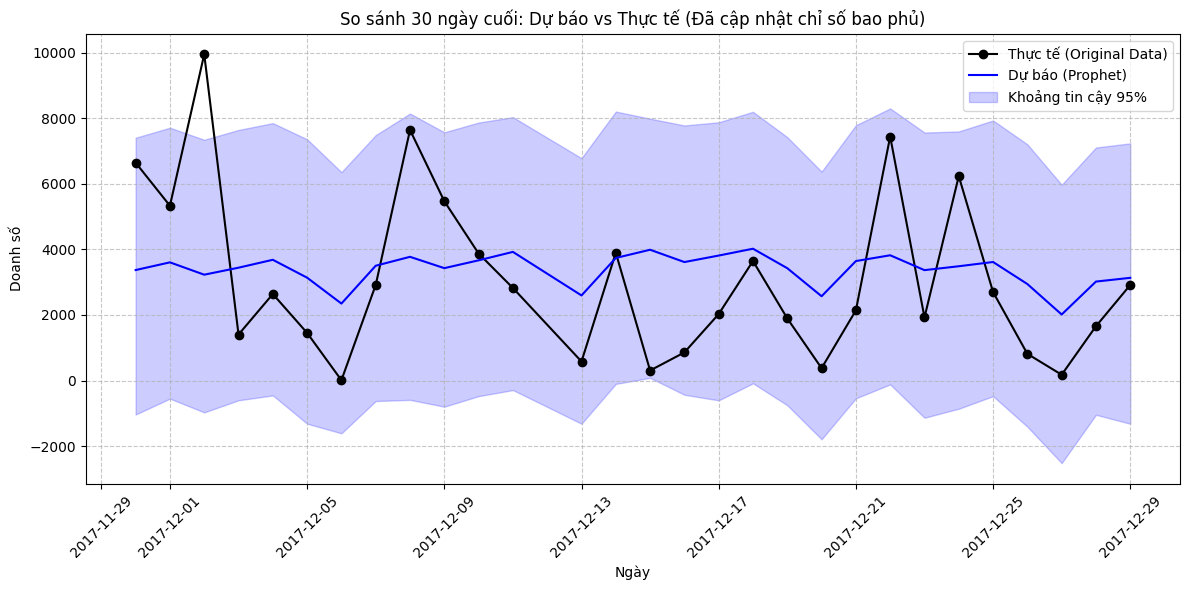

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

# 1. Tải và chuẩn bị dữ liệu
df_raw = pd.read_csv("SampleSuperstore.csv", encoding='latin-1')
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], format='%m/%d/%Y')

df_prophet = df_raw.groupby('Order Date')['Sales'].sum().reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet = df_prophet.sort_values('ds')

# 2. Chia dữ liệu (Train/Test)
train = df_prophet.iloc[:-30]
test = df_prophet.iloc[-30:]

# 3. Huấn luyện mô hình (95% interval)
model = Prophet(interval_width=0.95)
model.fit(train)

# 4. Dự báo cho 30 ngày
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast_test = forecast.iloc[-30:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# 5. So sánh và tính toán sai số
comparison = pd.merge(test, forecast_test, on='ds')
comparison['error'] = comparison['y'] - comparison['yhat']

# Tính toán các chỉ số điểm
mae = mean_absolute_error(comparison['y'], comparison['yhat'])
mape = mean_absolute_percentage_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))

# Kiểm tra xem giá trị thực tế có nằm trong khoảng [yhat_lower, yhat_upper] không
comparison['is_covered'] = (comparison['y'] >= comparison['yhat_lower']) & (comparison['y'] <= comparison['yhat_upper'])
coverage_ratio = comparison['is_covered'].mean()

print(f"--- KẾT QUẢ SO SÁNH 30 NGÀY CUỐI ---")
print(f"MAE  (Sai số tuyệt đối trung bình): {mae:.2f}")
print(f"RMSE (Căn bậc hai sai số bình phương): {rmse:.2f}")
print(f"MAPE (Phần trăm sai số trung bình): {mape:.2%}")
print(f"Tỷ lệ bao phủ (Empirical Coverage Ratio): {coverage_ratio:.2%} (Kỳ vọng: ~95%)")
print(f"------------------------------------")

# 6. Trực quan hóa
plt.figure(figsize=(12, 6))
plt.plot(comparison['ds'], comparison['y'], 'ko-', label='Thực tế (Original Data)')
plt.plot(comparison['ds'], comparison['yhat'], 'b-', label='Dự báo (Prophet)')
plt.fill_between(comparison['ds'],
                 comparison['yhat_lower'],
                 comparison['yhat_upper'],
                 color='blue', alpha=0.2, label='Khoảng tin cậy 95%')

plt.title('So sánh 30 ngày cuối: Dự báo vs Thực tế (Đã cập nhật chỉ số bao phủ)')
plt.xlabel('Ngày')
plt.ylabel('Doanh số')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Cell mới: Đánh giá mô hình tổng thể bằng Time-Series Cross Validation
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

print("Đang tiến hành Time-Series Cross Validation. Quá trình này có thể mất vài phút...")

# Khởi tạo mô hình mới trên TOÀN BỘ dữ liệu để cross-validation
full_model = Prophet(interval_width=0.95)
full_model.fit(df_prophet)

# Thực hiện Cross Validation
# - initial: Dùng 3 năm đầu (1095 ngày) làm tập huấn luyện khởi tạo
# - period: Mỗi lần dịch cửa sổ trượt đi 60 ngày
# - horizon: Dự báo cho 30 ngày tương lai ở mỗi nấc trượt
df_cv = cross_validation(full_model, initial='1095 days', period='60 days', horizon='30 days')

# Tính toán các chỉ số hiệu suất trên các nếp gấp (folds)
df_p = performance_metrics(df_cv)

print("\n--- BẢNG HIỆU SUẤT TỔNG THỂ (ROLLING WINDOW) ---")
print(df_p[['horizon', 'rmse', 'mae', 'mape', 'coverage']].head())

print("\n=> Chỉ số 'coverage' trong bảng trên chính là mức độ tin cậy thực tế của khoảng dự báo theo từng độ dài ngày.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Đang tiến hành Time-Series Cross Validation. Quá trình này có thể mất vài phút...


INFO:prophet:Making 6 forecasts with cutoffs between 2017-02-03 00:00:00 and 2017-11-30 00:00:00


  0%|          | 0/6 [00:00<?, ?it/s]


--- BẢNG HIỆU SUẤT TỔNG THỂ (ROLLING WINDOW) ---
  horizon         rmse          mae       mape  coverage
0  3 days  2254.965428  1709.652103  18.217892  0.933333
1  4 days  2614.756616  1934.782287  15.039594  0.811111
2  5 days  2049.429748  1496.785338   8.720387  0.866667
3  6 days  2054.837756  1506.473254  17.053097  0.866667
4  7 days  1196.640215  1039.862060  16.272392  1.000000

=> Chỉ số 'coverage' trong bảng trên chính là mức độ tin cậy thực tế của khoảng dự báo theo từng độ dài ngày.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Đang tải và chuẩn bị dữ liệu...
Đang chạy Prophet...
Đang chạy SARIMA...
Đang chạy XGBoost...
Đang chạy LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH (30 NGÀY CUỐI) ---
  Model         MAE        RMSE    WMAPE
Prophet 2081.778201 2511.315152 0.690286
 SARIMA 3032.043656 3747.560286 1.005380
XGBoost 2009.975753 2792.244248 0.666477
   LSTM 1845.896937 2519.461975 0.612071


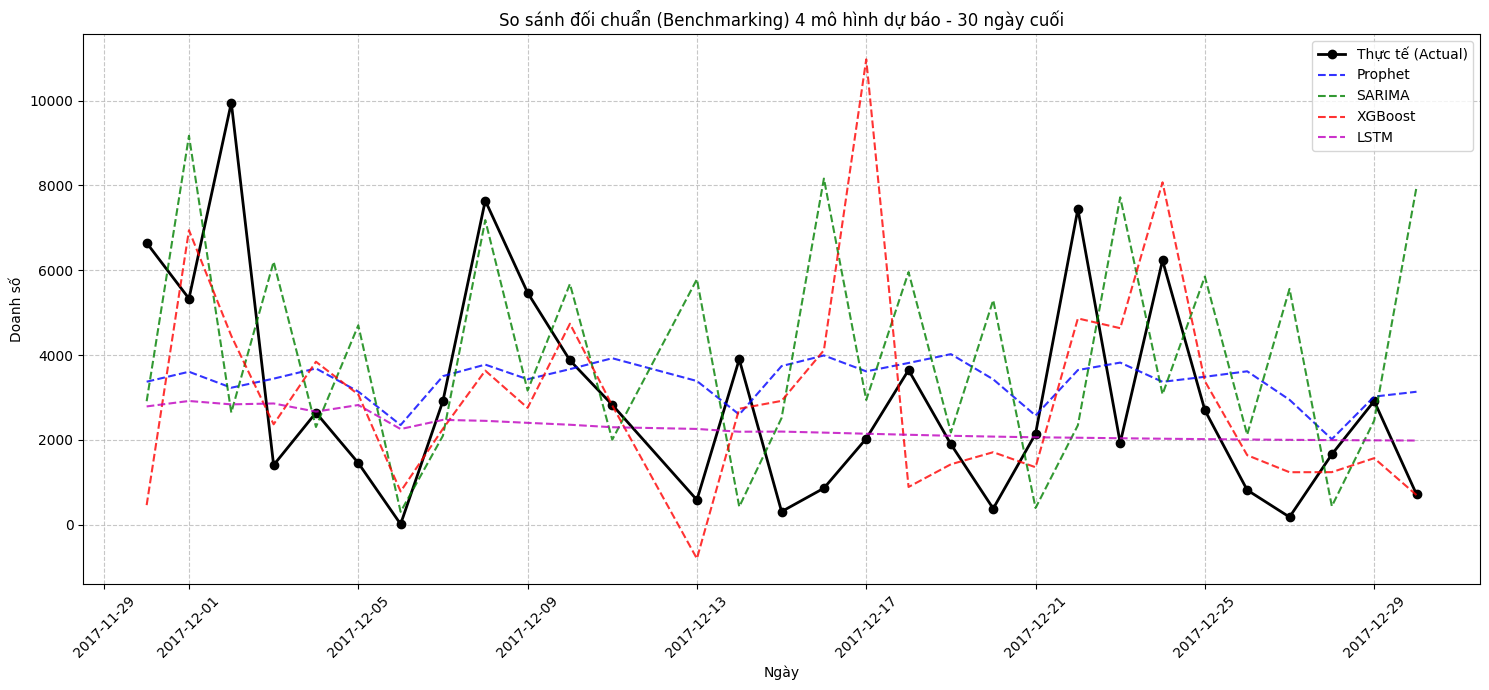

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Import các mô hình
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ---------------------------------------------------------
# 1. CÁC HÀM ĐÁNH GIÁ (METRICS)
# ---------------------------------------------------------
def calculate_wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wmape = calculate_wmape(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'WMAPE': wmape}

# ---------------------------------------------------------
# 2. CHUẨN BỊ DỮ LIỆU CHUNG
# ---------------------------------------------------------
print("Đang tải và chuẩn bị dữ liệu...")
df_raw = pd.read_csv("SampleSuperstore.csv", encoding='latin-1')
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], format='%m/%d/%Y')

df = df_raw.groupby('Order Date')['Sales'].sum().reset_index()
df.columns = ['ds', 'y']
df = df.sort_values('ds').reset_index(drop=True)

# Chia Train/Test (giữ lại đúng 30 ngày cuối)
test_size = 30
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

y_true = test['y'].values
results = []
predictions = {'Actual': y_true, 'Date': test['ds'].values}

# ---------------------------------------------------------
# 3. HUẤN LUYỆN VÀ DỰ BÁO CÁC MÔ HÌNH
# ---------------------------------------------------------

# --- MÔ HÌNH 1: PROPHET ---
print("Đang chạy Prophet...")
prophet_model = Prophet(interval_width=0.95)
prophet_model.fit(train)
future = prophet_model.make_future_dataframe(periods=test_size)
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.iloc[-test_size:]['yhat'].values

predictions['Prophet'] = prophet_pred
results.append(evaluate_model('Prophet', y_true, prophet_pred))

# --- MÔ HÌNH 2: SARIMA ---
print("Đang chạy SARIMA...")
# Cấu hình order=(1,1,1) và seasonal_order=(1,1,0,7) giả định tính mùa vụ theo tuần
sarima_model = SARIMAX(train['y'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 7))
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=test_size).values

predictions['SARIMA'] = sarima_pred
results.append(evaluate_model('SARIMA', y_true, sarima_pred))

# --- MÔ HÌNH 3: XGBOOST ---
print("Đang chạy XGBoost...")
# Feature Engineering cho XGBoost (Trích xuất đặc trưng từ ngày tháng)
def create_features(data):
    df_feat = data.copy()
    df_feat['dayofweek'] = df_feat['ds'].dt.dayofweek
    df_feat['month'] = df_feat['ds'].dt.month
    df_feat['dayofmonth'] = df_feat['ds'].dt.day
    df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)
    return df_feat

train_xgb = create_features(train)
test_xgb = create_features(test)

X_train_xgb = train_xgb[['dayofweek', 'month', 'dayofmonth', 'is_weekend']]
y_train_xgb = train_xgb['y']
X_test_xgb = test_xgb[['dayofweek', 'month', 'dayofmonth', 'is_weekend']]

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_pred = xgb_model.predict(X_test_xgb)

predictions['XGBoost'] = xgb_pred
results.append(evaluate_model('XGBoost', y_true, xgb_pred))

# --- MÔ HÌNH 4: LSTM (DEEP LEARNING) ---
print("Đang chạy LSTM...")
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[['y']])

# Tạo chuỗi dữ liệu (Lookback = 7 ngày) cho LSTM
lookback = 7
X_train_lstm, y_train_lstm = [], []
for i in range(lookback, len(scaled_train)):
    X_train_lstm.append(scaled_train[i-lookback:i, 0])
    y_train_lstm.append(scaled_train[i, 0])
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))

# Xây dựng mạng nơ-ron
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(lookback, 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=16, verbose=0)

# Dự báo trượt (Rolling Forecast) cho 30 ngày Test
lstm_pred_scaled = []
current_batch = scaled_train[-lookback:].reshape((1, lookback, 1))

for i in range(test_size):
    pred = lstm_model.predict(current_batch, verbose=0)[0]
    lstm_pred_scaled.append(pred)
    current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

predictions['LSTM'] = lstm_pred
results.append(evaluate_model('LSTM', y_true, lstm_pred))

# ---------------------------------------------------------
# 4. TỔNG HỢP VÀ TRỰC QUAN HÓA KẾT QUẢ
# ---------------------------------------------------------
# In bảng kết quả
results_df = pd.DataFrame(results)
print("\n--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH (30 NGÀY CUỐI) ---")
print(results_df.to_string(index=False))

# Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 7))
plt.plot(predictions['Date'], predictions['Actual'], 'ko-', linewidth=2, label='Thực tế (Actual)')
plt.plot(predictions['Date'], predictions['Prophet'], 'b--', alpha=0.8, label='Prophet')
plt.plot(predictions['Date'], predictions['SARIMA'], 'g--', alpha=0.8, label='SARIMA')
plt.plot(predictions['Date'], predictions['XGBoost'], 'r--', alpha=0.8, label='XGBoost')
plt.plot(predictions['Date'], predictions['LSTM'], 'm--', alpha=0.8, label='LSTM')

plt.title('So sánh đối chuẩn (Benchmarking) 4 mô hình dự báo - 30 ngày cuối')
plt.xlabel('Ngày')
plt.ylabel('Doanh số')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Đang chuẩn bị dữ liệu RFM...
Đang tiến hành huấn luyện và đo lường...

--- BẢNG KẾT QUẢ ĐỐI CHUẨN (BENCHMARKING) ---
         Algorithm  Clusters Found  Execution Time (s)  Silhouette Score  Davies-Bouldin Index
     K-Means (k=4)               4              0.0270            0.3582                0.9579
Hierarchical (k=4)               4              0.0356            0.3101                1.1589
  DBSCAN (eps=0.5)               1              0.0332            0.4782                1.6055


/tmp/ipykernel_3831/3958703459.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Algorithm", y="Execution Time (s)", ax=axes[0], palette="Blues_r")
/tmp/ipykernel_3831/3958703459.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Algorithm", y="Silhouette Score", ax=axes[1], palette="Greens_r")


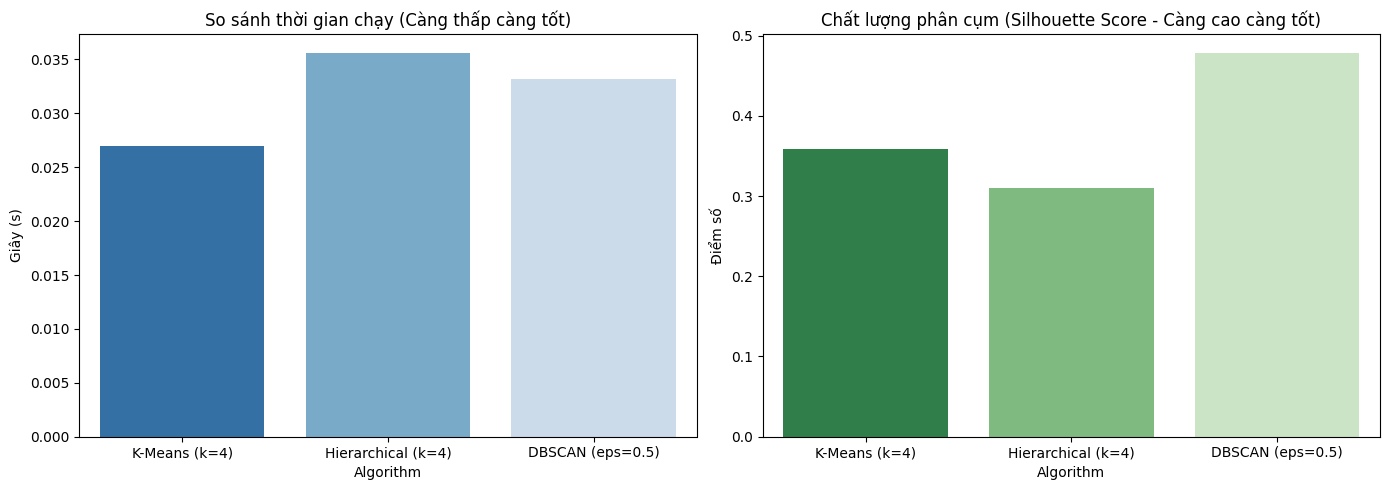

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU RFM (Tương tự như file 03-machine-learning.md của bạn)
print("Đang chuẩn bị dữ liệu RFM...")
df = pd.read_csv("SampleSuperstore.csv", encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
reference_date = df["Order Date"].max()

rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (reference_date - x.max()).days,  # Recency
    "Order ID": "count",  # Frequency
    "Sales": "sum"  # Monetary
}).reset_index()

rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary"]

# 2. CHUẨN HÓA DỮ LIỆU (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Khởi tạo từ điển lưu kết quả
results = []

# 3. ĐỊNH NGHĨA VÀ CHẠY CÁC MÔ HÌNH
models = {
    "K-Means (k=4)": KMeans(n_clusters=4, random_state=42, n_init=10),
    "Hierarchical (k=4)": AgglomerativeClustering(n_clusters=4),
    "DBSCAN (eps=0.5)": DBSCAN(eps=0.5, min_samples=5) # Thông số mặc định phổ biến
}

print("Đang tiến hành huấn luyện và đo lường...\n")
for name, model in models.items():
    # Đo thời gian chạy
    start_time = time.time()
    labels = model.fit_predict(X_scaled)
    execution_time = time.time() - start_time

    # Bỏ qua việc tính điểm nếu DBSCAN chỉ tìm được 1 cụm hoặc toàn nhiễu (-1)
    if len(set(labels)) > 1:
        # Silhouette Score: Càng gần 1 càng tốt (phân tách rõ)
        sil_score = silhouette_score(X_scaled, labels)
        # Davies-Bouldin Score: Càng thấp càng tốt (các cụm ít chồng lấn)
        db_score = davies_bouldin_score(X_scaled, labels)
        # Số lượng cụm tạo ra
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    else:
        sil_score = np.nan
        db_score = np.nan
        num_clusters = 0

    results.append({
        "Algorithm": name,
        "Clusters Found": num_clusters,
        "Execution Time (s)": round(execution_time, 4),
        "Silhouette Score": round(sil_score, 4) if pd.notna(sil_score) else "N/A",
        "Davies-Bouldin Index": round(db_score, 4) if pd.notna(db_score) else "N/A"
    })

# 4. IN BẢNG KẾT QUẢ SO SÁNH
results_df = pd.DataFrame(results)
print("--- BẢNG KẾT QUẢ ĐỐI CHUẨN (BENCHMARKING) ---")
print(results_df.to_string(index=False))

# 5. TRỰC QUAN HÓA SO SÁNH
# Lọc bỏ DBSCAN nếu nó bị lỗi không tạo được cụm hợp lệ (để vẽ biểu đồ)
plot_df = results_df[results_df["Silhouette Score"] != "N/A"].copy()
plot_df["Silhouette Score"] = plot_df["Silhouette Score"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Thời gian chạy (Thấp hơn là tốt hơn)
sns.barplot(data=results_df, x="Algorithm", y="Execution Time (s)", ax=axes[0], palette="Blues_r")
axes[0].set_title("So sánh thời gian chạy (Càng thấp càng tốt)")
axes[0].set_ylabel("Giây (s)")

# Biểu đồ 2: Silhouette Score (Cao hơn là tốt hơn)
sns.barplot(data=plot_df, x="Algorithm", y="Silhouette Score", ax=axes[1], palette="Greens_r")
axes[1].set_title("Chất lượng phân cụm (Silhouette Score - Càng cao càng tốt)")
axes[1].set_ylabel("Điểm số")

plt.tight_layout()
plt.show()